# Homework - 2

In this homework, you will learn:

1. How to code the [Transformer](https://arxiv.org/abs/1706.03762) architecture, an essential skill of the modern DL engineer.
2. How to work with different [HuggingFace](https://huggingface.co/) tools.
3. How to use LLM APIs.
4. Some techniques for efficient LLM fine-tuning.

As in the previous homework, we expect you to create configurable code and put all the cells in the chronological order, so your solution can be run sequentially. Also, you must use [Comet](https://www.comet.com/site/) for tracking (both for HuggingFace and PyTorch training tasks) and provide a Comet Report together with the `ipynb` notebook in your submission. 

LLM-generated code/analysis for tasks is strongly discouraged.

Penalties will be applied if these rules are not followed.

**Note** This homework will require you to use many tokens (HF, Groq, etc.). Do not submit them with your notebook. It is private information. Leakage of tokens will be penalized.

**Hint** Create a `.py` or `.env` file with all your tokens. Upload it to your working space (Kaggle/Colab) and import tokens from the file without ever exposing their values: `from private_tokens import HF_TOKEN`, for example.

# Ссылки

датасет https://huggingface.co/datasets/ldiujes/ai_text_detection_dataset_dl_hw_2_v6

репорт https://www.comet.com/m-dumbduck/hse-dl-hw-2/reports/H9vQ6oN1QN0KRdejPW5JPAKIQ

In [1]:
!pip install sacrebleu
!pip install bert-score
!pip install groq
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 12.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.6 MB/s eta 0:00:0000:01
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2


In [2]:
import os
import random
import shutil
import time
import gc

from tqdm import tqdm
from kaggle_secrets import UserSecretsClient
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from datasets import concatenate_datasets, DatasetDict, Dataset, load_dataset

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import asyncio
from groq import AsyncGroq

from sacrebleu import corpus_bleu
from sacrebleu.metrics import CHRF, TER
from bert_score import score

import comet_ml

from huggingface_hub import login

from tokenizers import decoders, models, normalizers, pre_tokenizers, processors, trainers, Tokenizer

from transformers import PreTrainedTokenizerFast, AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

In [3]:
secrets = UserSecretsClient()
os.environ["GROQ_API_KEY"] = secrets.get_secret("GROQ_API_KEY")
os.environ["HF_TOKEN"] = secrets.get_secret("HUGGINGFACE_API_KEY")
os.environ["COMET_API_KEY"] = secrets.get_secret("COMET_API_KEY")
os.environ["COMET_PROJECT_NAME"] = "hse-dl-hw-2"

In [4]:
login()

## Part I: Machine Translation

In this task, your goal is to learn how to code Transformer architecture and do autoregressive (AR) generation. We will focus on **Ru$\to$En** text translation.

### (Task 1) (1 pts)

Let's start by looking at the data and process it. Download the [En $\to$ Ru subset of Opus Books](https://huggingface.co/datasets/Helsinki-NLP/opus_books) and sample some examples from it to see how it looks.

In [5]:
data = load_dataset('Helsinki-NLP/opus_books', 'en-ru')

README.md: 0.00B [00:00, ?B/s]

en-ru/train-00000-of-00001.parquet:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17496 [00:00<?, ? examples/s]

In [6]:
data['train']['translation'][:5]

[{'en': 'Anna Karenina', 'ru': 'Анна Каренина'},
 {'en': 'Leo Tolstoy', 'ru': 'Толстой Лев Николаевич'},
 {'en': 'Vengeance is mine; I will repay.', 'ru': 'Мне отмщение, и аз воздам'},
 {'en': 'VOLUME ONE PART I', 'ru': 'ЧАСТЬ ПЕРВАЯ'},
 {'en': 'CHAPTER I', 'ru': 'I'}]

Split the dataset into a 9:1 train/test partitions. Use `seed=1`.

In [7]:
split = data['train'].train_test_split(test_size=0.1, seed=1)
train = split['train']
test = split['test']

For training a machine translator, we need to convert raw strings into token ID lists. So, we need a `tokenizer`. 

Let's learn how to train such a `tokenizer` from scratch. First, have a look at [this tutorial](https://huggingface.co/learn/llm-course/chapter6/8). Let's do the **BPE** variant with some differences:

1. Pre-tokenize using WhiteSpace.
2. Normalize all unicode characters (NFKC).
3. Add all the required special tokens needed for Machine Translation (recall that your model needs to know when the sentence starts and ends).
4. Use `WordPiece` decoder to correct decoding punctuation (try without it and see the issue)

For the vocabulary size, set a value between 8-16k.

Write down all the required code and train your tokenizer on all Ru/En text in the **train** partition of your dataset. Do not forget to convert the tokenizer into `FastTokenizer` using `PreTrainedTokenizerFast`.

In [8]:
def get_training_corpus(dataset):
    for i in range(0, len(dataset), 1000):
        yield [dataset['translation'][j]['en'] for j in range(i, min(len(dataset), i + 1000))] + \
                [dataset['translation'][j]['ru'] for j in range(i, min(len(dataset), i + 1000))]

In [9]:
def make_tokenizer(get_training_corpus, vocab_size, use_word_piece_decoder=True):
    tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
    tokenizer.normalizer = normalizers.NFKC()
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    if use_word_piece_decoder:
        trainer = trainers.BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=['[UNK]', '[BOS]', '[EOS]', '[PAD]'],
            continuing_subword_prefix='##'
        )
    else:
        trainer = trainers.BpeTrainer(
            vocab_size=vocab_size,
            special_tokens=['[UNK]', '[BOS]', '[EOS]', '[PAD]'],
        )
    tokenizer.train_from_iterator(get_training_corpus(train), trainer)
    bos_token_id = tokenizer.token_to_id('[BOS]')
    eos_token_id = tokenizer.token_to_id('[EOS]')
    pad_token_id = tokenizer.token_to_id('[PAD]')
    tokenizer.post_processor = processors.TemplateProcessing(
        single='[BOS] $A [EOS]',
        special_tokens=[('[BOS]', bos_token_id), ('[EOS]', eos_token_id)],
    )
    if use_word_piece_decoder:
        tokenizer.decoder = decoders.WordPiece(prefix='##')
    tokenizer = PreTrainedTokenizerFast(
        tokenizer_object=tokenizer,
        unk_token= "[UNK]",
        bos_token="[BOS]",
        eos_token="[EOS]",
        pad_token = "[PAD]"
    )
    return tokenizer

In [10]:
tokenizer = make_tokenizer(get_training_corpus, 16000, use_word_piece_decoder=False)
print(tokenizer.decode(tokenizer.encode("I love big fat hippos.")))




[BOS] I love big fat hip pos . [EOS]


In [11]:
tokenizer = make_tokenizer(get_training_corpus, 16000, use_word_piece_decoder=True)
print(tokenizer.decode(tokenizer.encode("I love big fat hippos.")))




[BOS] I love big fat hippos. [EOS]


decoders.WordPiece помог избавиться, например, от того, что между последним словом в предложении и точкой пробел (как я понял, он улучшает положение пробелов относительно пунктуации). Еще я добавил continuing_subword_prefix='##', чтобы hippos не распадался на два слова, что очень важно, так как скоры, ориенирующиеся на слова, могут сильно падать, если мы режем слово на два.

Sample some examples from the dataset and encode / decode them. Verify that your code is working.

In [12]:
indices = random.sample(range(len(train)), 3)
sample = train.select(indices)
for elem in sample['translation']:
    language = random.choice(['en', 'ru'])
    encoding = tokenizer.encode(elem[language])
    decoded = tokenizer.decode(encoding, skip_special_tokens=True)
    print(elem[language], '\n')
    print(encoding, '\n')
    print(decoded, '\n')
    print('\n', '-' * 30, '\n')

Он был счастлив, но совсем не так, как ожидал. 

[1, 591, 660, 5997, 10, 420, 2213, 293, 500, 10, 415, 5977, 12, 2] 

Он был счастлив, но совсем не так, как ожидал. 


 ------------------------------ 

И он, как трещотка, загремел каблуками, сбегая с лестницы. 

[1, 101, 353, 10, 415, 1794, 204, 423, 317, 10, 6751, 849, 308, 11982, 1345, 10, 139, 1034, 3935, 139, 11796, 12, 2] 

И он, как трещотка, загремел каблуками, сбегая с лестницы. 


 ------------------------------ 

Yes, you will come for a day and go away again, as men do...' 

[1, 1059, 10, 379, 703, 962, 401, 54, 1014, 290, 600, 1129, 920, 10, 389, 1836, 508, 1164, 2] 

Yes, you will come for a day and go away again, as men do...' 


 ------------------------------ 



### (Task 2) (1 pts)


Create your own implementation of the Transformer architecture. Use sinusoidal positional encoding and an **encoder-decoder** style. You **are not allowed to use `nn.Transformer` and other `PyTorch` Transformer-related layers; other lirbraries, e.g. `HuggingFace`, are also banned**. You can only use `nn.Linear`, activation layers, and `nn.LayerNorm` with `nn.Dropout`. Use pre-norm style

$$
y_t = x_t + \text{MHA}(\text{LN}(x_t)), \qquad x_{t+1} = y_t + \text{FFN}(\text{LN}(y_t))
$$

Every Deep Learning Engineer should at least once try to write `Transformer` on their own, so do not try to cheat.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0, causal_masking=False, bias=True):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.causal_masking = causal_masking
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.DRP = nn.Dropout(dropout)
        self.WQ = nn.Linear(d_model, d_model, bias=False)
        self.WK = nn.Linear(d_model, d_model, bias=False)
        self.WV = nn.Linear(d_model, d_model, bias=False)
        self.W0 = nn.Linear(d_model, d_model, bias=bias)

    def forward(self, X, pad_mask):
        L = X.shape[1]
        
        Q = self.WQ(X)
        K = self.WK(X)
        V = self.WV(X)

        Q = Q.reshape(-1, L, self.n_heads, self.d_head).transpose(1, 2)
        KT = K.reshape(-1, L, self.n_heads, self.d_head).permute(0, 2, 3, 1)
        V = V.reshape(-1, L, self.n_heads, self.d_head).transpose(1, 2)

        QKT_normed = Q @ KT / self.d_head ** 0.5
        
        QKT_normed = QKT_normed.masked_fill(pad_mask[:, torch.newaxis, torch.newaxis, :], -torch.inf)
        
        if self.causal_masking:
            mask = torch.tril(torch.ones_like(QKT_normed, dtype=bool))
            QKT_normed[~mask] = -torch.inf
            
        attn = torch.softmax(QKT_normed, dim=-1)
        attn = self.DRP(attn)

        result = attn @ V

        result = result.transpose(1, 2).reshape(-1, L, self.d_model)
   
        return self.W0(result)
        


class CrossMultiHeadAttention(MultiHeadAttention):
    def __init__(self, d_model, n_heads, dropout=0.0, bias=True):
        super().__init__(d_model, n_heads, dropout=dropout, bias=bias)

    def forward(self, enc_embeds, enc_mask, dec_embeds, dec_mask):
        L_enc = enc_embeds.shape[1]
        L_dec = dec_embeds.shape[1]
        
        Q = self.WQ(dec_embeds)
        K = self.WK(enc_embeds)
        V = self.WV(enc_embeds)

        Q = Q.reshape(-1, L_dec, self.n_heads, self.d_head).transpose(1, 2)
        KT = K.reshape(-1, L_enc, self.n_heads, self.d_head).permute(0, 2, 3, 1)
        V = V.reshape(-1, L_enc, self.n_heads, self.d_head).transpose(1, 2)

        QKT_normed = Q @ KT / self.d_head ** 0.5
        QKT_normed = QKT_normed.masked_fill(enc_mask[:, torch.newaxis, torch.newaxis, :], -torch.inf)
        
        attn = torch.softmax(QKT_normed, dim=-1)
        attn = self.DRP(attn)

        result = attn @ V

        result = result.transpose(1, 2).reshape(-1, L_dec, self.d_model)
   
        return self.W0(result)


class FeedForward(nn.Module):
    def __init__(self, d_in_out, d_internal, bias=True):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_in_out, d_internal, bias=bias),
            nn.ReLU(),
            nn.Linear(d_internal, d_in_out, bias=bias)
        )

    def forward(self, X):
        return self.layers(X)


class Encoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0, causal_masking=False, bias=True):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.LN1 = nn.LayerNorm(d_model)
        self.MHA = MultiHeadAttention(d_model, n_heads, dropout=dropout, causal_masking=causal_masking, bias=bias)
        self.DRP1 = nn.Dropout(dropout)
        self.LN2 = nn.LayerNorm(d_model)
        self.FF = FeedForward(d_model, d_ff, bias=bias)
        self.DRP2 = nn.Dropout(dropout)

    def forward(self, embeds, mask):
        embeds = embeds + self.DRP1(self.MHA(self.LN1(embeds), mask))
        return embeds + self.DRP2(self.FF(self.LN2(embeds)))


class Decoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0, bias=True):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.LN1 = nn.LayerNorm(d_model)
        self.MHA = MultiHeadAttention(d_model, n_heads, dropout=dropout, causal_masking=True, bias=bias)
        self.DRP1 = nn.Dropout(dropout)
        self.LN2 = nn.LayerNorm(d_model)
        self.CMHA = CrossMultiHeadAttention(d_model, n_heads, dropout=dropout, bias=bias)
        self.DRP2 = nn.Dropout(dropout)
        self.LN3 = nn.LayerNorm(d_model)
        self.FF = FeedForward(d_model, d_ff, bias=bias)
        self.DRP3 = nn.Dropout(dropout)

    def forward(self, enc_embeds, enc_mask, dec_embeds, dec_mask):
        dec_embeds = dec_embeds + self.DRP1(self.MHA(self.LN1(dec_embeds), dec_mask))
        dec_embeds = dec_embeds + self.DRP2(self.CMHA(enc_embeds, enc_mask, self.LN2(dec_embeds), dec_mask))
        return dec_embeds + self.DRP3(self.FF(self.LN3(dec_embeds)))


def add_positional_sinusoidal_encoding(X, d_model):
    pos = torch.arange(X.shape[1], device=X.device, dtype=X.dtype)
    d_ind = torch.arange(X.shape[2], device=X.device, dtype=X.dtype)
    PE = torch.zeros_like(X)
    PE[:, :, ::2] = torch.sin(
        pos[torch.newaxis, :, torch.newaxis]
        / 10000 ** (d_ind[torch.newaxis, torch.newaxis, ::2] / d_model)
    )
    PE[:, :, 1::2] = torch.cos(
        pos[torch.newaxis, :, torch.newaxis]
        / 10000 ** ((d_ind[torch.newaxis, torch.newaxis, 1::2] - 1) / d_model)
    )
    return X + PE

        
class Transformer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_enc, n_dec, vocab_size, dropout=0.0):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.d_model = d_model
        self.n_heads = n_heads
        self.vocab_size = vocab_size
        self.EMBED = nn.Embedding(vocab_size, d_model)
        self.DRP_EMB_ENC = nn.Dropout(dropout)
        self.DRP_EMB_DEC = nn.Dropout(dropout)
        self.ENCs = nn.ModuleList([Encoder(d_model, n_heads, d_ff, dropout=dropout) for _ in range(n_enc)])
        self.DECs = nn.ModuleList([Decoder(d_model, n_heads, d_ff, dropout=dropout) for _ in range(n_dec)])
        self.LinHead = nn.Linear(d_model, vocab_size)

    def forward(self, enc_tokens, enc_pad_mask, dec_tokens, dec_pad_mask):
        enc_embeds = self.EMBED(enc_tokens)
        dec_embeds = self.EMBED(dec_tokens)
        
        enc_embeds = add_positional_sinusoidal_encoding(enc_embeds, self.d_model)
        dec_embeds = add_positional_sinusoidal_encoding(dec_embeds, self.d_model)

        enc_embeds = self.DRP_EMB_ENC(enc_embeds)
        dec_embeds = self.DRP_EMB_DEC(dec_embeds)

        for ENC in self.ENCs:
            enc_embeds = ENC(enc_embeds, enc_pad_mask)
        for DEC in self.DECs:
            dec_embeds = DEC(enc_embeds, enc_pad_mask, dec_embeds, dec_pad_mask)
        return self.LinHead(dec_embeds)

    def forward_train(self, enc_tokens, enc_pad_mask, dec_tokens, dec_pad_mask):
        logits = self.forward(enc_tokens, enc_pad_mask, dec_tokens[:, :-1], dec_pad_mask[:, :-1])
        return logits, dec_tokens[:, 1:]

### (Task 3) (0.5 pts)

Create a `translate` function that will take English text as input and translate in using your model in a **greedy-decoding** way, i.e., at each prediction step you should take the token with the highest probability.

In [14]:
def translate(tokens_for_encoder, enc_pad_mask, model, tokenizer, device):
    model.eval()
    B = tokens_for_encoder.shape[0]
    tokens_for_decoder = torch.full((B, 1), tokenizer.bos_token_id, device=device)
    active_inds = torch.arange(B, device=device)
    end_token_id = tokenizer.eos_token_id
    output_texts = [None for _ in range(B)]
    cnt = 0
    with torch.no_grad():
        while active_inds.shape[0] > 0 and cnt < 2 * tokens_for_encoder.shape[1]:
            dec_pad_mask = torch.zeros_like(tokens_for_decoder, dtype=bool)
            logits = model(tokens_for_encoder, enc_pad_mask, tokens_for_decoder, dec_pad_mask)[:, -1]
            best_token_ids = torch.argmax(logits, dim=1)
            tokens_for_decoder = torch.cat([tokens_for_decoder, best_token_ids.unsqueeze(1)], dim=1)

            just_ended = best_token_ids == end_token_id
            for ind, translated_seq in zip(active_inds[just_ended], tokens_for_decoder[just_ended]):
                output_texts[ind] = tokenizer.decode(translated_seq[1:-1].tolist())
            
            tokens_for_decoder = tokens_for_decoder[~just_ended]
            tokens_for_encoder = tokens_for_encoder[~just_ended]
            enc_pad_mask = enc_pad_mask[~just_ended]
            active_inds = active_inds[~just_ended]
            cnt += 1

    for ind, translated_seq in zip(active_inds, tokens_for_decoder):
        output_texts[ind] = tokenizer.decode(translated_seq[1:].tolist())
    return output_texts

### (Task 4) (1.0 pts)

Create a `Dataset` class to train Transformer on it. _We want to translate Russian text into English (**Ru $\to$ En**)_.

Train your `Transformer` on the train partition you obtained in Task 1 and achieve at least $7.5$ BLEU score (use `sacrebleu` lib) on the test split. For the training loop, write your own code, do not use ready-to-use Trainers. Do not forget about logging, `collate_fn` for padding, and corresponding masking.

**Hint** The `CrossEntropyLoss` has an `ignore_index` field. If you set it to `pad_token_id`, you won't need to handle padding in the loss yourself. 

**Hint 2** It might be useful to log BLEU for train partition (or subset) as well.


In [15]:
class RuEnDataset(Dataset):
    def __init__(self, translations: list[dict]):
        self.translations = translations

    def __len__(self):
        return len(self.translations)

    def __getitem__(self, ind):
        ru_text = self.translations[ind]['ru']
        en_text = self.translations[ind]['en']
        ru_tokens = torch.tensor(tokenizer.encode(ru_text))
        en_tokens = torch.tensor(tokenizer.encode(en_text))
        return ru_tokens, en_tokens, en_text, ru_text

In [16]:
def pad_sequences(batch):
    max_len = max(len(tokens_vec) for tokens_vec in batch)
    result = torch.full((len(batch), max_len), tokenizer.pad_token_id, dtype=batch[0].dtype)
    mask = torch.zeros_like(result, dtype=bool)
    for i, tokens_vec in enumerate(batch):
        result[i, :len(tokens_vec)] = tokens_vec
        mask[i, len(tokens_vec):] = 1
    return result, mask

def pad_collate_fn(batch):
    batch_ru_tokens, batch_en_tokens, batch_en_text, batch_ru_text = zip(*batch)
    return pad_sequences(batch_ru_tokens), pad_sequences(batch_en_tokens), batch_en_text, batch_ru_text

In [17]:
train_dataset = RuEnDataset(train['translation'])
test_dataset = RuEnDataset(test['translation'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=pad_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=pad_collate_fn)

In [18]:
def train_epoch(epoch, model, criterion, optimizer, scheduler, loader, tokenizer, device, exp):
    model.train()
    
    avg_batch_loss = 0
    total_batches = 0

    for (ru_tokens, ru_pad_mask), (en_tokens, en_pad_mask), en_texts, ru_texts in tqdm(loader):
        ru_tokens = ru_tokens.to(device)
        ru_pad_mask = ru_pad_mask.to(device)
        en_tokens = en_tokens.to(device)
        en_pad_mask = en_pad_mask.to(device)

        optimizer.zero_grad()
        output, targets = model.forward_train(ru_tokens, ru_pad_mask, en_tokens, en_pad_mask)
        loss = criterion(output.transpose(1, 2), targets)
        loss.backward()
        optimizer.step()
        scheduler.step()

        exp.log_metrics({
            "train_step_loss": loss.item(),
            "train_step_lr": scheduler.get_last_lr()[0],
        }, step=epoch * len(loader) + total_batches)
        
        total_batches += 1
        avg_batch_loss += loss.item()

    avg_batch_loss /= total_batches
    return avg_batch_loss


def evaluate(model, criterion, loader, tokenizer, device, calc_bleu=False):
    model.eval()

    predicted_texts = []
    references = []

    avg_batch_loss = 0
    total_batches = 0

    with torch.no_grad():
        for (ru_tokens, ru_pad_mask), (en_tokens, en_pad_mask), en_texts, ru_texts in tqdm(loader):
            ru_tokens = ru_tokens.to(device)
            ru_pad_mask = ru_pad_mask.to(device)
            en_tokens = en_tokens.to(device)
            en_pad_mask = en_pad_mask.to(device)

            output, targets = model.forward_train(ru_tokens, ru_pad_mask, en_tokens, en_pad_mask)
            loss = criterion(output.transpose(1, 2), targets)

            total_batches += 1
            avg_batch_loss += loss.item()

            if calc_bleu:
                output_text = translate(ru_tokens, ru_pad_mask, model, tokenizer, device)
        
                predicted_texts += output_text
                references += en_texts

    avg_batch_loss /= total_batches
    if not calc_bleu:
        return avg_batch_loss

    bleu = corpus_bleu(predicted_texts, [references]).score
    return avg_batch_loss, bleu

In [23]:
def train_transformer(model, train_loader, test_loader, criterion, optimizer, scheduler, tokenizer, device, n_epochs, blue_in_epochs, exp_name):
    exp = comet_ml.Experiment(project_name=os.environ["COMET_PROJECT_NAME"], log_git_metadata=False, log_git_patch=False)
    exp.set_name(exp_name)
    for epoch in range(1, n_epochs + 1):
        train_avg_batch_loss = train_epoch(epoch, model, criterion, optimizer, scheduler, train_loader, tokenizer, device, exp)
        metrics_to_log = {}
        if epoch % blue_in_epochs == 0:
            test_avg_batch_loss, test_bleu = evaluate(model, criterion, test_loader, tokenizer, device, calc_bleu=True)
            metrics_to_log["test_bleu"] = test_bleu
            print(f'Epoch {epoch}/{n_epochs} finished with {train_avg_batch_loss=:.5f}, {test_avg_batch_loss=:.5f}, {test_bleu=:.3f}')
        else:
            test_avg_batch_loss = evaluate(model, criterion, test_loader, tokenizer, device, calc_bleu=False)
            print(f'Epoch {epoch}/{n_epochs} finished with {train_avg_batch_loss=:.5f}, {test_avg_batch_loss=:.5f}')

        metrics_to_log["train_avg_batch_loss"] = train_avg_batch_loss
        metrics_to_log["test_avg_batch_loss"] = test_avg_batch_loss
        exp.log_metrics(metrics_to_log, step=epoch * len(train_loader))
    exp.end()

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [25]:
NUM_EPOCHS = 10

transformer = Transformer(d_model=512, n_heads=8, d_ff=2048, n_enc=3, n_dec=3, dropout=0.2, vocab_size=tokenizer.vocab_size).to(device)
print(f"total parameters: {sum(p.numel() for p in transformer.parameters())}")

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

optimizer = torch.optim.AdamW(transformer.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
    T_max=NUM_EPOCHS * len(train_loader), eta_min=1e-4
)

total parameters: 38455424


In [26]:
train_transformer(transformer, train_loader, test_loader, criterion, optimizer, scheduler, tokenizer, device, NUM_EPOCHS, bleu_in_epochs=2, exp_name="transformer_translation")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/m-dumbduck/hse-dl-hw-2/21f7970fa50f42afa277f0091ccf4f76

100%|██████████| 55/55 [00:04<00:00, 11.18it/s]


Epoch 1/10 finished with train_avg_batch_loss=5.46968, test_avg_batch_loss=4.83545


100%|██████████| 55/55 [01:35<00:00,  1.73s/it]


Epoch 2/10 finished with train_avg_batch_loss=4.49903, test_avg_batch_loss=4.43441, test_bleu=3.167


100%|██████████| 55/55 [00:04<00:00, 11.22it/s]


...

Epoch 8/10 finished with train_avg_batch_loss=2.59530, test_avg_batch_loss=4.00917, test_bleu=7.532


100%|██████████| 55/55 [00:04<00:00, 11.17it/s]


Epoch 9/10 finished with train_avg_batch_loss=2.42437, test_avg_batch_loss=4.02098


100%|██████████| 55/55 [00:49<00:00,  1.10it/s]
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : transformer_translation
COMET INFO:     url                   : https://www.comet.com/m-dumbduck/hse-dl-hw-2/21f7970fa50f42afa277f0091ccf4f76
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     test_avg_batch_loss [10]  : (3.965336006337946, 4.835451342842796)
COMET INFO:     test_bleu [5]             : (3.1673253639217434, 8.205875785134825)
COMET INFO:     train_avg_batch_loss [10] : (2.2904447733026005, 5.469677929462332)
COMET INFO:     train_step_loss [4930]    : (0.8740208745002747, 10.106071472167969)
COMET INFO:     train_step_lr [4930]      : (0.0001, 0.00029999997969626683)
COMET INFO:  

Epoch 10/10 finished with train_avg_batch_loss=2.29044, test_avg_batch_loss=4.05792, test_bleu=8.206


Run the final evaluation and show the BLEU score:

In [27]:
test_avg_batch_loss, test_bleu = evaluate(transformer, criterion, test_loader, tokenizer, device, calc_bleu=True)
print(f"BLEU score: {test_bleu}")

100%|██████████| 55/55 [00:49<00:00,  1.11it/s]


BLEU score: 8.205875785134825


### (Task 5) (0.75 pts)

In the LLM lecture, we discussed that most tasks can be re-formulated in the decoder-only style. Create a prefix-decoder version of your `Transformer` and train it on the same data. 

**Note** you need to separate Russian text from the English version. One can do it using a `SEP` special token in the tokenizer. But we will investigate another option - continuous embedding. When provided to the Transformer, all tokens are converted to embeddings based on token ids, but you do not need to have an id to get an embedding. Indeed, you can just create a parameter in your transformer and concatenate it with the input Russian sequence. This trainable parameter will tell the model that subsequent tokens should be in English.

$$
[h_{\text{Ru}}, h_{\text{trainable sep. embedding}}, h_{\text{En}}]
$$

**Hint** A simple way to calculate loss only on English tokens in the prefix decoder is to utilize the `ignore_index` field of `CrossEntropyLoss`. Think what should you do with the target you pass to the loss to avoid calculating loss on Russian tokens.


**For fair comparison, make sure to use the same training setup as the encoder-decoder variant and use similar number of parameters.**

In [34]:
class PrefixDecoderTransformer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_dec, vocab_size, dropout=0.0):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model must be divisible by n_heads")
        self.d_model = d_model
        self.n_heads = n_heads
        self.vocab_size = vocab_size
        self.EMBED = nn.Embedding(vocab_size, d_model)
        self.SEP_EMBED = nn.Parameter(torch.randn(d_model))
        self.DECs = nn.ModuleList([Encoder(d_model, n_heads, d_ff, causal_masking=True, dropout=dropout) for _ in range(n_dec)])
        self.LinHead = nn.Linear(d_model, vocab_size)

    def forward(self, enc_tokens, enc_pad_mask, dec_tokens, dec_pad_mask):
        B = enc_tokens.shape[0]
        enc_lens = (~enc_pad_mask).sum(dim=1)
        dec_lens = (~dec_pad_mask).sum(dim=1)
        max_len = torch.max(enc_lens + dec_lens + 1)

        enc_embeds = self.EMBED(enc_tokens)
        dec_embeds = self.EMBED(dec_tokens)

        all_embeds = torch.zeros((B, max_len, self.d_model), device=enc_embeds.device, dtype=enc_embeds.dtype)
        all_pad_mask = torch.zeros((B, max_len), device=enc_pad_mask.device, dtype=torch.bool)
        
        for i in range(B):
            all_embeds[i, :enc_lens[i]] = enc_embeds[i, :enc_lens[i]]
            all_embeds[i, enc_lens[i]] = self.SEP_EMBED
            all_embeds[i, enc_lens[i]+1:enc_lens[i]+dec_lens[i]+1] = dec_embeds[i, :dec_lens[i]]
            all_pad_mask[i, enc_lens[i]+dec_lens[i]+1:] = 1
        
        all_embeds = add_positional_sinusoidal_encoding(all_embeds, self.d_model)

        for DEC in self.DECs:
            all_embeds = DEC(all_embeds, all_pad_mask)
            
        logits = self.LinHead(all_embeds)
        max_dec_len = torch.max(dec_lens)
        result_logits = torch.zeros((B, max_dec_len, self.vocab_size), dtype=logits.dtype, device=logits.device)
        for i in range(B):
            result_logits[i, :dec_lens[i], :] = logits[i, enc_lens[i]+1:enc_lens[i]+1+dec_lens[i], :]
        return result_logits

    def forward_train(self, enc_tokens, enc_pad_mask, dec_tokens, dec_pad_mask):
        logits = self.forward(enc_tokens, enc_pad_mask, dec_tokens[:, :-1], dec_pad_mask[:, :-1])
        return logits, dec_tokens[:, 1:]

In [35]:
NUM_EPOCHS = 10

prefix_decoder_transformer = PrefixDecoderTransformer(d_model=512, n_heads=8, d_ff=2048, n_dec=6, dropout=0.2, vocab_size=tokenizer.vocab_size).to(device)
print(f"total parameters: {sum(p.numel() for p in prefix_decoder_transformer.parameters())}")

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

optimizer = torch.optim.AdamW(prefix_decoder_transformer.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
    T_max=NUM_EPOCHS * len(train_loader), eta_min=1e-4
)

total parameters: 35305600


In [36]:
train_transformer(prefix_decoder_transformer, train_loader, test_loader, criterion, optimizer, scheduler, tokenizer, device, NUM_EPOCHS, blue_in_epochs=2, exp_name="prefix_decoder_transformer_translation")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/m-dumbduck/hse-dl-hw-2/a74d8b25dcd14904946ff7963290a7ef

100%|██████████| 55/55 [00:07<00:00,  7.57it/s]


Epoch 1/10 finished with train_avg_batch_loss=5.32396, test_avg_batch_loss=4.77129


100%|██████████| 55/55 [01:27<00:00,  1.59s/it]


Epoch 2/10 finished with train_avg_batch_loss=4.31771, test_avg_batch_loss=4.39934, test_bleu=3.729


100%|██████████| 55/55 [00:07<00:00,  7.53it/s]


...

Epoch 8/10 finished with train_avg_batch_loss=1.99498, test_avg_batch_loss=4.48363, test_bleu=6.145


100%|██████████| 55/55 [00:07<00:00,  7.51it/s]


Epoch 9/10 finished with train_avg_batch_loss=1.75310, test_avg_batch_loss=4.58703


100%|██████████| 55/55 [01:39<00:00,  1.80s/it]
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : prefix_decoder_transformer_translation
COMET INFO:     url                   : https://www.comet.com/m-dumbduck/hse-dl-hw-2/a74d8b25dcd14904946ff7963290a7ef
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     test_avg_batch_loss [10]  : (4.16447563604875, 4.771288585662842)
COMET INFO:     test_bleu [5]             : (3.7294111597773623, 6.144563967151359)
COMET INFO:     train_avg_batch_loss [10] : (1.5638893487245509, 5.323957390040461)
COMET INFO:     train_step_loss [4930]    : (1.132500171661377, 10.10250473022461)
COMET INFO:     train_step_lr [4930]      : (0.0001, 0.00029999997969626683)
C

Epoch 10/10 finished with train_avg_batch_loss=1.56389, test_avg_batch_loss=4.70669, test_bleu=5.811


In [37]:
test_avg_batch_loss, test_bleu = evaluate(prefix_decoder_transformer, criterion, test_loader, tokenizer, device, calc_bleu=True)
print(f"BLEU score: {test_bleu}")

100%|██████████| 55/55 [01:38<00:00,  1.79s/it]


BLEU score: 5.810519661032764


### (Task 6) (0.75 pts)

Model analysis can be done in two ways. "Quantitative" is based on metrics (scores) and is usually conducted over the whole dataset to get some objective measure. "Qualitative" is more subjective but required to see if the scores make sense. The latter evaluation means showing some examples of model generations and manually analyzing their quality. 

**Quantitative** What other metrics apart from BLEU can be used to evaluate the performance of machine translation? Choose at least 2 other metrics and calculate their scores for both Transformer models.

**Qualitative** Sample 5 translations for each model. 



In [42]:
def get_translated_texts(model, loader):
    sources = []
    hypotheses = []
    references = []
    
    with torch.no_grad():
        for (ru_tokens, ru_pad_mask), (en_tokens, en_pad_mask), en_texts, ru_texts in tqdm(loader):
            ru_tokens = ru_tokens.to(device)
            ru_pad_mask = ru_pad_mask.to(device)
            en_tokens = en_tokens.to(device)
            en_pad_mask = en_pad_mask.to(device)
            output_text = translate(ru_tokens, ru_pad_mask, model, tokenizer, device)
            hypotheses += output_text
            references += en_texts
            sources += ru_texts

    return sources, hypotheses, references


def calculate_and_print_scores(sources, hypotheses, references):
    chrf_score = CHRF().corpus_score(hypotheses, [references])
    bert_P, bert_R, bert_F1 = score(
        hypotheses,
        references,
        lang="en",
        device="cuda"
    )
    bleu_score = corpus_bleu(hypotheses, [references]).score
    
    print(f"CHRF score: {chrf_score}")
    print(f"BERT score Precision: {bert_P.mean().item():.4f}")
    print(f"BERT score Recall: {bert_R.mean().item():.4f}")
    print(f"BERT score F1: {bert_F1.mean().item():.4f}")
    print(f"BLEU score: {bleu_score}")
    print()

    random.seed(52)
    random_inds = random.sample(range(len(sources)), 5)
    
    for ind in random_inds:
        print('-' * 60, '\n')
        print(f"SOURCE: {sources[ind]}\n")
        print(f"HYPOTHESE: {hypotheses[ind]}\n")
        print(f"REFERENCE: {references[ind]}\n")


In [43]:
calculate_and_print_scores(*get_translated_texts(transformer, test_loader))

100%|██████████| 55/55 [00:46<00:00,  1.17it/s]


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CHRF score: chrF2 = 29.55
BERT score Precision: 0.8782
BERT score Recall: 0.8801
BERT score F1: 0.8790
BLEU score: 8.205875785134825

------------------------------------------------------------ 

SOURCE: Левин открыл рот, хотел сказать что-то, покраснел и ничего не сказал.

HYPOTHESE: Levin opened his mouth and wished to say something, and said nothing.

REFERENCE: Levin opened his mouth to reply, but blushed and said nothing.

------------------------------------------------------------ 

SOURCE: Она рада была, что не поехала никуда и так хорошо провела этот вечер.

HYPOTHESE: She was glad that she had not so well and so well that evening.

REFERENCE: She was glad she had not gone out that evening but had spent it so pleasantly at home.

------------------------------------------------------------ 

SOURCE: -- Нет, я думаю, без шуток, что для того, чтоб узнать любовь, надо ошибиться и потом поправиться, -- сказала княгиня Бетси.

HYPOTHESE: ' No, I think without the least hesitation,

In [44]:
calculate_and_print_scores(*get_translated_texts(prefix_decoder_transformer, test_loader))

100%|██████████| 55/55 [01:33<00:00,  1.69s/it]


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CHRF score: chrF2 = 26.46
BERT score Precision: 0.8687
BERT score Recall: 0.8729
BERT score F1: 0.8707
BLEU score: 5.810519661032764

------------------------------------------------------------ 

SOURCE: Левин открыл рот, хотел сказать что-то, покраснел и ничего не сказал.

HYPOTHESE: Levin smiled, but had gone to tell the Prince, and did not tell anything.

REFERENCE: Levin opened his mouth to reply, but blushed and said nothing.

------------------------------------------------------------ 

SOURCE: Она рада была, что не поехала никуда и так хорошо провела этот вечер.

HYPOTHESE: She was pleased that she was not so well for her to see her mistress.

REFERENCE: She was glad she had not gone out that evening but had spent it so pleasantly at home.

------------------------------------------------------------ 

SOURCE: -- Нет, я думаю, без шуток, что для того, чтоб узнать любовь, надо ошибиться и потом поправиться, -- сказала княгиня Бетси.

HYPOTHESE: ' No, I think that the chief thin

Explain the choice of your metrics and how they differ from each other. Do they allow to evaluate different aspects of translation? Which is primary (the most important)? Do metrics reflect what you see in the generated samples? What can you say about the quality of samples for each model, how do they differ? Then, compare encoder-decoder and prefix-decoder variants in terms of convergence speed, model quality, etc.. Explain the observations and write down a conclusion.

**YOUR RESPONSE HERE**

Я выбрал CHRF метрику и BERT score метрику. 

CHRF метрика - это метрика, похожая на BLEU, но CHRF работает с символьными n-граммами в отличие от BLEU. Если модель предсказывает слова, но делает ошибки в их формах или путает буквы внутри них, то CHRF должен относиться к этому более мягко, в отличие от BLEU. 

BERT score сравнивает эмбеддинги токенов в hypothese и reference. Эта метрика, в отличие от CHRF и BLEU, уже напрямую отражает то, как хорошо модель предсказывает смысл текста.

Я бы не сказал, что какой-либо аспект или метрика являются более важными, чем другие. Переведенный текст должен быть похож на reference и по семантике, и по смыслу, и по синтаксическим особенностям, и т д. И в единой метрике это отразить непросто. Понятно, что BLEU очень тяжелая для выбивания метрика, потому что она требует того, чтобы hypothes и refernce были очень похожи по словам и их порядку, а перевод по хорошему допускает не единственность. Поэтому надо оценивать комплекс метрик.

Метрики в комплексе достаточно хорошо отражают качество перевода. Например на этом примере:

**SOURCE**: Левин открыл рот, хотел сказать что-то, покраснел и ничего не сказал.

**HYPOTHESE**: Levin opened his mouth and wished to say something, and said nothing.

**REFERENCE**: Levin opened his mouth to reply, but blushed and said nothing.

У нас гипотеза и референс очень похожи по смыслу, но reference гораздо более выразительный. однако так как ембеддинги близки, то в среднем BERT score получается хороший.

В целом, наглядное качество перевода примерно одинаковое для обеих моделей. У обеих моделей встречаются бессмысленны повторения словосочетаний в одном предложении: например, `Levin had long since his long since his mother had long since he had long since the winter in Moscow, he was in Moscow with his place`. Метрики кроме BLEU отличаются мало. Малое отличие BERT score в частности говорит, что обе модели хорошо поняли переводы отдельных слов и маленьких словосочетаний по смыслу, так как BERT score довольно высокий.

В целом, encoder-decoder transformer показал результат лучше, prefix-decoder transformer, и обучался быстрее по времени на эпоху, а также сошелся быстрее. Скорее всего это связано с тем, что мы склеиваем `encoder_tokens` и `decoder_tokens` в случае prefix-decoder transformer, и уже считаем аттеншн на этом (а аттеншн это $O((L_{enc} + L_{dec})^2)$), из-за чего возникает оверхед.

Обе архитектуры хорошие. Prefix-decoder более простая в реализации и более простая как концепция.



## Part II: Detection of Machine-generated Text

In the LLM era, synthesized texts appear everywhere. Your goal is to design and train a text deepfake detector. 

Deepfake detection (in any modality) posses significant challenges related to out-of-domain generatlization, i.e., having high prediction accuracy on unseen data likely generated via unseen LLMs. Indeed, new synthesizers are developed every week and it is impossible to have samples from all of them in the training set, especially for proprietary models. Furthermore, collecting enough examples for each LLM is time-consuming and expensive.

This puts the task in the classic setup of scarce amount of labeled data with the need to still having robust performance in the wild. As we saw in class, a common approach would be to use a pre-trained large backbone that already knows how the real data should look like and how to extract meaningful concepts and, then, fine-tune this backbone on our small labeled dataset. 

In this homework, we will do exactly this. We will take a pre-trained [RoBERTa](https://huggingface.co/FacebookAI/roberta-base) and fine-tune it on a self-collected dataset of human\AI text pairs.

For the dataset, the **train partition will be collected by yourself**. You will evaluate your model on the **validation** split provided [here](https://huggingface.co/datasets/Blinorot/DLR_HW2_VAL) (label = 1 means human). All tasks below must log accuracy on this validation split. Then, in the bonus task, you will have a comptetition on a [test set](https://huggingface.co/datasets/Blinorot/DLR_HW2_TEST). **You cannot use provided datasets for training**.

In [6]:
text_ai_detection_val = load_dataset('Blinorot/DLR_HW2_VAL')
text_ai_detection_test = load_dataset('Blinorot/DLR_HW2_TEST')

README.md:   0%|          | 0.00/360 [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.99M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/6214 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/309 [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.74M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/6236 [00:00<?, ? examples/s]

In [7]:
text_ai_detection_val

DatasetDict({
    validation: Dataset({
        features: ['text', 'label', 'uniq_id'],
        num_rows: 6214
    })
})

In [8]:
text_ai_detection_val = text_ai_detection_val['validation']

In [9]:
import numpy as np

lengths = np.array([len(row['text']) for row in text_ai_detection_val])
labels = np.array(text_ai_detection_val['label'])
print("mean length:", np.mean(lengths), ", std:", np.std(lengths))
print("mean ai-written length", np.mean(lengths[labels == 0]), ", std:", np.std(lengths[labels == 0]))
print("mean human-written length", np.mean(lengths[labels == 1]), ", std:", np.std(lengths[labels == 1]))

mean length: 2345.3134856775023 , std: 1922.9882906813307
mean ai-written length 1739.2031807854592 , std: 1658.7713545344616
mean human-written length 2941.3638684966486 , std: 1977.8751076976898


### (Task 7) Dataset Collection [2 pts]

We need to have both real text examples and AI-generated examples, so the model learns to differentiate between them. For the real partition, find any dataset (**you can use train partition only**) on HuggingFace that contains **only human-written** text. Make sure you use only **training partitions** of the datasets to avoid contamination.

For AI-generated texts, all of them **must be collected yourself** using`openai` + [vllm](https://github.com/vllm-project/vllm) serving with HuggingFace models (any that will fit in your Kaggle/Colab GPU) or **free** [Groq](https://groq.com/) APIs (see the documentation to understand how to use `groq`).

Combine all your data (real + generated) into a HuggingFace `datasets.DatasetDict` and upload it on you HuggingFace account. Attach the collected dataset link in the homework submission system.

**Hint** investigate the validation split we provided to understand what type of texts you will need to handle. Provided texts are generated by many LLMs and techniques.

Describe your dataset creation strategy. What libraries and models do you use, what real data do you use, what prompts do you use, etc. Make sure to include your reasoning behind each design choice.

**YOUR STRATEGY DESCRIPTION HERE:** 

#### Human-written texts

Я решил использовать датасет euclaise/WritingPromptsX, потому что по стилистике (вайбу) он похож на то, что у нас есть в Blinorot/DLR_HW2_VAL. Этот датасет написано, что inspired by writingprompts dataset, а тот датасет из статьи (https://arxiv.org/pdf/1805.04833), в абстракте которой написано, что датасет был собран следующим обращом: "We collect a large dataset of 300K human-written stories paired with writing prompts from an online forum". То есть это большой датасет human-written texts с достаточно широким содержанием. Понятно, что на онлайн форуме (Reddit) могут встречаться артефакты, какие-то проблемные обсуждения и т д, но с другой стороны, в большинстве своем это именно human-written и при этом в датасете именно story. writingprompts датасет размера 272600, а WritingPromptsX 1245546, что побольше. Также размер датасета сильно больше, чем размер Blinorot/DLR_HW2_VAL, поэтому можно придумывать достаточно строгие фильтры и все равно останется много примеров.

#### AI-written texts

Так как наш датасет содержит топики в онлайн форуме, то мы можем попробовать использовать эти топики в промптах при составлении ai-written texts части train выборки. Глобально, будет сделано следующее: часть топиков мы будем использовать с чисто human текстами, для части топиков будет нагенерен чисто ai версия ответа на топик, а для еще одной части топиков мы возьмем пару: пример human текста по топику, и пример ai текста по нему.

In [122]:
human_text_dataset = load_dataset('euclaise/WritingPromptsX')
human_text_dataset

README.md:   0%|          | 0.00/732 [00:00<?, ?B/s]

data/train-00000-of-00005-b5fb0e1f754c66(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00005-18d2e86864109e(…):   0%|          | 0.00/199M [00:00<?, ?B/s]

data/train-00002-of-00005-ff15d47dc4afd0(…):   0%|          | 0.00/181M [00:00<?, ?B/s]

data/train-00003-of-00005-1e09e3ad68ab12(…):   0%|          | 0.00/199M [00:00<?, ?B/s]

data/train-00004-of-00005-18a7153c0afa1a(…):   0%|          | 0.00/188M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1245546 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['post_title', 'body', 'score', 'gilded', 'post_score', '__index_level_0__'],
        num_rows: 1245546
    })
})

In [123]:
human_text_dataset = human_text_dataset['train']

In [125]:
lengths = np.array([len(row['body']) for row in human_text_dataset])
print("mean length:", np.mean(lengths), ", max length:", np.max(lengths), ", std:", np.std(lengths))

mean length: 1441.9679594330519 , max length: 39538 , std: 1802.8574575489524


пофильтруем датасет, так как в нем могут быть очень большие тексты, или тексты, в которых написана несуразица, и нет структуры предложений, или много символов не текст. еще у нас есть колонки 'score', 'gilded', 'post_score', которые можно использовать для фильтрации

In [132]:
def filter_human_written_dataset(x):
    if not 100 <= len(x["body"]) <= 5000:
        return False
    if x["score"] < 1:
        return False
    if x["post_score"] < 1:
        return False
    if x["body"].count(".") + x["body"].count("!") + x["body"].count("?") < 5:
        return False
    if sum(c.isalpha() for c in x["body"]) / len(x["body"]) < 0.6:
        return False
    return True

human_text_dataset_filtered = human_text_dataset.filter(filter_human_written_dataset)

In [133]:
human_text_dataset_filtered

Dataset({
    features: ['post_title', 'body', 'score', 'gilded', 'post_score', '__index_level_0__'],
    num_rows: 724514
})

In [135]:
lengths = np.array([len(row['body']) for row in human_text_dataset_filtered])
print("mean length:", np.mean(lengths), ", max length:", np.max(lengths), ", std:", np.std(lengths))

mean length: 1700.6767502077255 , max length: 5000 , std: 1155.110570496795


средняя длина согласуется с тем что есть в вале. давайте поанализируем, что у нас в post_title.

In [136]:
lengths = np.array([len(row['post_title']) for row in human_text_dataset_filtered])
print("mean length:", np.mean(lengths), ", max length:", np.max(lengths), ", std:", np.std(lengths))

mean length: 152.23317147770783 , max length: 323 , std: 82.44565857740285


In [137]:
np.random.seed(54)
inds = np.random.randint(0, len(human_text_dataset_filtered), 5)

for i in inds:
    print('-------POST_TITLE-------\n')
    print(human_text_dataset_filtered['post_title'][int(i)])

-------POST_TITLE-------

[WP] You have just won $100 Million Dollars in the lottery. The next day, you receive a phone call with, news...
-------POST_TITLE-------

[WP] You live in a computer simulation. Recently, the simulation is having glitches, and weird things are happening all over the universe.
-------POST_TITLE-------

[WP] You have the ability to stop time at will. However there are others with the same ability in the world and when they stop time you can still move. In a normal day, there are random moments when time stops and It's starting to get on your nerves.
-------POST_TITLE-------

[WP] Life is a book, and the writer is changed every year. 2016's writer is the most incompetent one yet. Describe his relationship with the previous writers.
-------POST_TITLE-------

[CW] Write a short story in which the main character dies after every other sentence.


[WP] и т д, которые мы видим это что-то типа пометок ответов на какие-то обсуждения. Нам это совсем не надо, и, вооще говоря, будет мешать. Так что давайте почистим такие штуки с помощью регекса который убирает произвольное количество чего-либо в квадратных скобках в начале строки

In [139]:
import re

def clean_prompt(example):
    example["post_title"] = re.sub(
        r'^(?:\s*\[\s*[^\]]+?\s*\]\s*)+',
        '',
        example["post_title"]
    ).strip()
    return example

human_text_dataset_filtered = human_text_dataset_filtered.map(clean_prompt)

Map:   0%|          | 0/724514 [00:00<?, ? examples/s]

колонка `post_title` задает топик темы, поэтому может быть такое, что на одном топике много разных историй

In [141]:
df = human_text_dataset_filtered.to_pandas()
df["clean_post_title"] = df["post_title"].str.strip()

df_unique = df.drop_duplicates(subset=["clean_post_title"], keep="first").drop(columns=["clean_post_title"])

human_text_dataset_filtered_unique = Dataset.from_pandas(df_unique, preserve_index=False)
len(human_text_dataset_filtered_unique)

371669

Получилось, что дубликатов было очень много. Давайте оставим по одному bode на post_title, то есть будем работать с `human_text_dataset_unique`. Вариативность разных body на один промпт это тоже хорошо, однако в таком случае это нужно балансировать ai story на post_title, а здесь вариативность может быть гораздо меньше. Поэтому давайте оставим уникальные.

In [142]:
human_text_dataset = human_text_dataset_filtered_unique

In [144]:
np.random.seed(52)
inds = np.random.randint(0, len(human_text_dataset), 1)

for i in inds:
    print('-' * 60, '\n')
    print('-------PROMPT-------\n')
    print(human_text_dataset_filtered['post_title'][int(i)], '\n')
    print('-------STORY-------\n')
    print(human_text_dataset_filtered['body'][int(i)], '\n')

------------------------------------------------------------ 

-------PROMPT-------

The Slaver and his Boy 

-------STORY-------

Birds took to the sky as the man on horseback raised his standard and shouted a challenge to the perimeter guards he knew were there, out of sight.

“Darius Thalgood, Captain in the White Legion and landowner requests access to the Dome City of Melthamnus!”

As the commotion of the birds died down, Darius was left with the sound of the wind through the tall grass. Nothing. There were always guards at the water crossings into the outskirts of Malthamnus. He looked around for some sign of life across the field and saw nothing.

Deliberating for a long while, Darius decided to press forward to the gates of the city; or until he was stopped by the city guard. He tugged on the long rope, causing the bound boy to stumble on the slick river rocks.

“Come. And keep quiet.”

The boy looked up, confused and pleading. Darius knew he didn't speak the common tongue and 

я решил, что надо чтоб какие-то генерации имели человеко-сгенерированные аналоги, а другие просто были из датасета. то есть некоторая часть промптов используется и в human-written, и в ai-written, чтобы моделька училась находить отличия на текстах близких по смыслу, а не запоминала, какая тема текста больше свойственная той или иной группе.

In [145]:
human_text_dataset_shuffled = human_text_dataset.shuffle(seed=53)
human_text_dataset_shuffled = human_text_dataset_shuffled.add_column("prompt_id", np.arange(len(human_text_dataset_shuffled)))

TEXT_DATASET_FOR_BOTH_LEN = 2000
TEXT_DATASET_FOR_HUMAN_LEN = 3000
TEXT_DATASET_FOR_AI_LEN = 3000
text_dataset_for_both = human_text_dataset_shuffled.select(range(0, TEXT_DATASET_FOR_BOTH_LEN))
text_dataset_for_human = human_text_dataset_shuffled.select(range(TEXT_DATASET_FOR_BOTH_LEN, TEXT_DATASET_FOR_BOTH_LEN+TEXT_DATASET_FOR_HUMAN_LEN))
text_dataset_for_ai = human_text_dataset_shuffled.select(range(TEXT_DATASET_FOR_BOTH_LEN+TEXT_DATASET_FOR_HUMAN_LEN, TEXT_DATASET_FOR_BOTH_LEN+TEXT_DATASET_FOR_HUMAN_LEN+TEXT_DATASET_FOR_AI_LEN))

Flattening the indices:   0%|          | 0/371669 [00:00<?, ? examples/s]

я попросил chatgpt сгенерить мне промпты-обертки для топиков, потому что я слышал, что модельками очень хорошо генерировать промпты для моделек. Таким образом, мой трейн датасет будет состоять из похожих текстов на human written, а значит и на val, так как human-written у меня с форума, что похоже на то что в val. Получается, что мой готовящийся датасет и вал по идее будут из одного распределения, что хорошо. Еще, чтобы достигнуть разнообразия в длинах текстов, я добавил length hints

In [148]:
prompt_wrappers = [
    """Write a story from this prompt.
Do not make it overly polished or neatly structured.
Let it feel natural, specific, and a little rough around the edges if that fits.
{length_hint}

{prompt}""",

    """Reply to this prompt with a story.
No title. No explanation. Just the story.
Keep the voice natural and direct rather than polished.
{length_hint}

{prompt}""",

    """Write the story.
Do not aim for elegance for its own sake.
If the scene feels tense, awkward, strange, or uncomfortable, let that remain in the writing.
{length_hint}

{prompt}""",

    """Use this prompt and write a story that feels like it was written by a real person with a distinct voice.
Avoid generic uplift, fake profundity, and overly neat closure.
{length_hint}

{prompt}""",

    """Write this like fiction someone might actually post online, not like a carefully edited workshop piece.
Keep it grounded, specific, and unforced.
{length_hint}

{prompt}""",

    """Turn this prompt into a story.
Start close to the moment itself.
Do not waste too much time on setup or explanation.
{length_hint}

{prompt}""",

    """Write a story from this prompt.
Let the voice feel lived-in and specific.
Do not sanitize every awkward, tense, or emotionally messy moment.
{length_hint}

{prompt}""",

    """Answer this like a piece of fiction written with some real feeling behind it,
not like something trying to sound universally polished or literary.
No title. No explanation.
{length_hint}

{prompt}""",

    """Write the story.
It can be jagged, funny, dark, awkward, or uncomfortable if that suits the prompt.
Do not smooth everything out or force a perfectly clean ending.
{length_hint}

{prompt}""",

    """Use the prompt below and write a story with a natural, unpolished voice.
Do not make everyone sound composed, graceful, or self-aware in the same way.
{length_hint}

{prompt}""",

    """Write a story based on this prompt.
Do not make it read like a careful short story exercise.
Let it feel like somebody actually means what they are saying.
{length_hint}

{prompt}""",

    """Write the story in a voice that feels immediate and specific.
Avoid overly clean transitions, tidy emotional packaging, and broad summary where concrete moments would work better.
{length_hint}

{prompt}""",

    """Reply to this prompt with fiction that feels human and not overly edited.
Do not wrap it in a moral or over-explain what the reader should feel.
{length_hint}

{prompt}""",

    """Use this prompt and write the kind of story that stands out because it has an actual voice,
not because it sounds polished.
No title. No explanation.
{length_hint}

{prompt}""",

    """Write from this prompt in first person if that feels natural.
Let the narration feel personal, immediate, and not overly filtered.
{length_hint}

{prompt}""",

    """Write the story.
Do not make every sentence clean, balanced, or graceful.
Aim for presence, conflict, and texture more than polish.
{length_hint}

{prompt}""",

    """Take this prompt and write fiction that feels alive rather than well-behaved.
It can be awkward, sharp, strange, or emotionally messy, but it should still feel like a real story.
No framing text.
{length_hint}

{prompt}""",
]

length_hints = {
    200: "Keep it short.",
    250: "Keep it short.",
    300: "Keep it short.",
    350: "Keep it fairly short.",
    400: "Keep it fairly short.",
    450: "Keep it fairly short.",
    500: "Write a medium-length story.",
    600: "Make it moderately long.",
    700: "Let it run a bit longer if it needs to.",
    800: "Write a longer story if the prompt supports it.",
    900: "Write a longer story if the prompt supports it.",
}

In [149]:
random.seed(52)

lengths = list(length_hints.keys())

prompts_both_part = []
for row in text_dataset_for_both:
    max_tokens = random.choice(lengths)
    prompts_both_part.append(
        (random.choice(prompt_wrappers).format(prompt=row["post_title"], length_hint=length_hints[max_tokens]), row["prompt_id"], max_tokens)
    )

prompts_ai_only_part = []
for row in text_dataset_for_ai:
    max_tokens = random.choice(lengths)
    prompts_ai_only_part.append(
        (random.choice(prompt_wrappers).format(prompt=row["post_title"], length_hint=length_hints[max_tokens]), row["prompt_id"], max_tokens)
    )

In [150]:
for prompt in random.sample(prompts_both_part, 3):
    print('-' * 60)
    print(prompt)

------------------------------------------------------------
('Reply to this prompt with fiction that feels human and not overly edited.\nDo not wrap it in a moral or over-explain what the reader should feel.\nWrite a longer story if the prompt supports it.\n\nA daughters song', 293, 800)
------------------------------------------------------------
('Write the story in a voice that feels immediate and specific.\nAvoid overly clean transitions, tidy emotional packaging, and broad summary where concrete moments would work better.\nKeep it short.\n\nThe war between humans and dragons went on for centuries. With not many left humans thought they had won, until they discovered that they learned that cutting off their tails made them fly longer and faster without being exhausted so quickly. Their one weakness, gone.', 1479, 250)
------------------------------------------------------------
('Write a story from this prompt.\nLet the voice feel lived-in and specific.\nDo not sanitize every awkw

я асинхронно отправлял большое количество запросов на groq, собирая датасет батчами. Я рандомлю температуру, чтобы разнообразить выборку. Еще используется 2 llm-ки, чтобы исключить характерный почерк одной llm. Если вознкнет вопрос почему у меня распараллеливание не степень двойки, то при 16 начинают иногда вылетать ошибки от того, что groq не может быстро принимать столько запросов.

In [151]:
async def generate_one(client, prompt, prompt_id, max_tokens, sem):
    async with sem:
        try:
            model = random.choice(["llama-3.1-8b-instant", "openai/gpt-oss-20b"])
            temperature = random.choice([0.7, 0.8, 0.9])
            max_completion_tokens = max_tokens
            top_p = 1
            if model == "openai/gpt-oss-20b":
                completion = await client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": prompt}],
                    reasoning_effort="low",
                    include_reasoning=False,
                    temperature=temperature,
                    max_completion_tokens=max_completion_tokens,
                    top_p=top_p,
                    stream=False,
                )
            else:
                completion = await client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=temperature,
                    max_completion_tokens=max_completion_tokens,
                    top_p=top_p,
                    stream=False,
                )

            text = completion.choices[0].message.content

            return {
                "prompt": prompt,
                "prompt_id": prompt_id,
                "model": model,
                "temperature": temperature,
                "max_completion_tokens": max_completion_tokens,
                "top_p": top_p,
                "text": text,
                "label": 0,
                "error": None,
            }

        except Exception as exc:
            return {
                "prompt": prompt,
                "prompt_id": prompt_id,
                "model": model,
                "temperature": temperature,
                "max_completion_tokens": max_completion_tokens,
                "top_p": top_p,
                "text": None,
                "label": None,
                "error": str(exc),
            }


async def get_groq_dataset_async(prompts, concurrency):
    client = AsyncGroq(api_key=os.environ["GROQ_API_KEY"])
    sem = asyncio.Semaphore(concurrency)

    tasks = [generate_one(client, prompt, prompt_id, max_tokens, sem) for prompt, prompt_id, max_tokens in prompts]
    rows = await asyncio.gather(*tasks)

    return Dataset.from_list(rows)

In [152]:
async def generate_groq_in_batches(prompts, step, concurrency):
    partial_datasets = []

    for i in tqdm(range(0, len(prompts), step)):
        batch_prompts = prompts[i:i + step]
        batch_dataset = await get_groq_dataset_async(batch_prompts, concurrency=concurrency)
        partial_datasets.append(batch_dataset)

    return concatenate_datasets(partial_datasets)

In [153]:
groq_dataset_for_both = await generate_groq_in_batches(
    prompts_both_part,
    step=256,
    concurrency=12
)

100%|██████████| 8/8 [02:45<00:00, 20.68s/it]


In [156]:
groq_dataset_for_ai = await generate_groq_in_batches(
    prompts_ai_only_part,
    step=256,
    concurrency=12
)

100%|██████████| 12/12 [04:00<00:00, 20.05s/it]


In [157]:
errors_groq_for_both = [i['error'] for i in groq_dataset_for_both if i['error'] is not None]
errors_groq_for_ai = [i['error'] for i in groq_dataset_for_ai if i['error'] is not None]
print('Num rows with errors groq_for_both:', len(errors_groq_for_both), '\n')
print(errors_groq_for_both[:3], '\n')
print('Num rows with errors groq_for_both:', len(errors_groq_for_ai), '\n')
print(errors_groq_for_ai[:3], '\n')

Num rows with errors groq_for_both: 0 

[] 

Num rows with errors groq_for_both: 0 

[] 



я сделаю датасет с двумя partitions: paired, unique. в paired будут на каждый уникальный топик один ai текст и один human текст. в unique будет на каждый уникальный топик либо один ai текст, либо один human текст. Еще добавлена колонка `prompt_id`, чтобы можно было при желании делить `paired` partition на части в которых тоже будут только пары

In [158]:
ai_for_paired = groq_dataset_for_both.remove_columns(["prompt", 'model', 'temperature', 'max_completion_tokens', 'top_p'])
ai_for_paired_good_prompt_ids = [ai_for_paired[i]['prompt_id'] for i in range(len(ai_for_paired)) if ai_for_paired[i]["error"] is None]
ai_for_paired = ai_for_paired.filter(lambda x: x['error'] is None).remove_columns(["error"])
ai_for_paired

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt_id', 'text', 'label'],
    num_rows: 2000
})

In [161]:
human_for_paired = text_dataset_for_both.remove_columns(['post_title', 'score', 'gilded', 'post_score', '__index_level_0__'])
human_for_paired = human_for_paired.filter(lambda x: x['prompt_id'] in ai_for_paired_good_prompt_ids)
human_for_paired = human_for_paired.add_column("label", [1] * len(human_for_paired))
human_for_paired = human_for_paired.rename_column("body", "text")
human_for_paired

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'prompt_id', 'label'],
    num_rows: 2000
})

In [162]:
human_for_unique = text_dataset_for_human.remove_columns(['post_title', 'score', 'gilded', 'post_score', '__index_level_0__'])
human_for_unique = human_for_unique.add_column("label", [1] * len(human_for_unique))
human_for_unique = human_for_unique.rename_column("body", "text")
human_for_unique

Dataset({
    features: ['text', 'prompt_id', 'label'],
    num_rows: 3000
})

In [163]:
ai_for_unique = groq_dataset_for_ai.remove_columns(["prompt", 'model', 'temperature', 'max_completion_tokens', 'top_p'])
ai_for_unique = ai_for_unique.filter(lambda x: x['error'] is None).remove_columns(["error"])
ai_for_unique

Filter:   0%|          | 0/3000 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt_id', 'text', 'label'],
    num_rows: 3000
})

In [164]:
ai_detection_dataset = DatasetDict({
    "paired": concatenate_datasets([ai_for_paired, human_for_paired]),
    "unique": concatenate_datasets([ai_for_unique, human_for_unique])
})

In [165]:
ai_detection_dataset.push_to_hub("ldiujes/ai_text_detection_dataset_dl_hw_2_v6")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/ldiujes/ai_text_detection_dataset_dl_hw_2_v6/commit/bcafd4631448b75305ea09da0bec2f685c60409a', commit_message='Upload dataset', commit_description='', oid='bcafd4631448b75305ea09da0bec2f685c60409a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/ldiujes/ai_text_detection_dataset_dl_hw_2_v6', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ldiujes/ai_text_detection_dataset_dl_hw_2_v6'), pr_revision=None, pr_num=None)

Provide the final statistics for your dataset: how many examples per each AI tool do you have, how many examples total, what data domains do you cover (if multiple), etc.

In [166]:
ai_detection_dataset

DatasetDict({
    paired: Dataset({
        features: ['prompt_id', 'text', 'label'],
        num_rows: 4000
    })
    unique: Dataset({
        features: ['prompt_id', 'text', 'label'],
        num_rows: 6000
    })
})

In [167]:
print(f"Unique ai count {len(ai_detection_dataset['unique']['label']) - np.sum(ai_detection_dataset['unique']['label']):}")
print(f"Unique human count {np.sum(ai_detection_dataset['unique']['label']):}")

Unique ai count 3000
Unique human count 3000


Filter:   0%|          | 0/4000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4000 [00:00<?, ? examples/s]

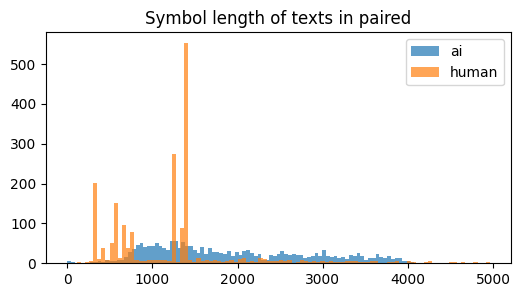

Filter:   0%|          | 0/6000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6000 [00:00<?, ? examples/s]

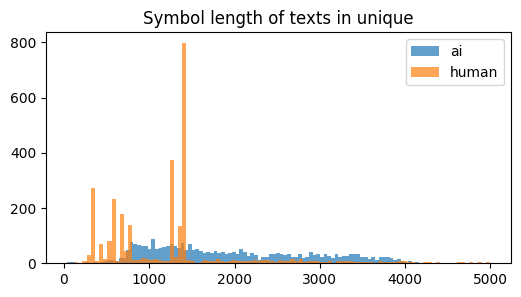

In [168]:
plt.figure(figsize=(6, 3))
plt.title("Symbol length of texts in paired")
plt.hist([len(row['text']) for row in ai_detection_dataset['paired'].filter(lambda x: x['label'] == 0)], bins=100, label="ai", alpha=0.7)
plt.hist([len(row['text']) for row in ai_detection_dataset['paired'].filter(lambda x: x['label'] == 1)], bins=100, label="human", alpha=0.7)
plt.legend()
plt.show()

plt.figure(figsize=(6, 3))
plt.title("Symbol length of texts in unique")
plt.hist([len(row['text']) for row in ai_detection_dataset['unique'].filter(lambda x: x['label'] == 0)], bins=100, label="ai", alpha=0.7)
plt.hist([len(row['text']) for row in ai_detection_dataset['unique'].filter(lambda x: x['label'] == 1)], bins=100, label="human", alpha=0.7)
plt.legend()
plt.show()

**YOUR DATASET STATISTICS DESCRIPTION HERE**

Датасет состоит из двух партишнов, unique и paired. в каждом из них примерно поровну ai и human generated текстов. тексты не очень большие: в основном 1000-2000 символов. Хвост длинных текстов до 5000 символов. Для unique и paired распределения очень схожи. AI тексты сгенерированы моделями llama 3.1 8b и gpt oss 20b.

### (Task 8) RoBERTa fine-tuning [1 pts]

Using your collected dataset and `transformers` library, download the `RoBERTa` [weights](https://huggingface.co/FacebookAI/roberta-base) and fine-tune it on the collected dataset with the `Trainer` class. 

Take a subset of your dataset and use it for validation. Log scores both on your's and teacher's validation. Clearly separate these two metrics in your logs.

To get full points, we expect you to achieve at least 70% accuracy on the [teacher's validation split](https://huggingface.co/datasets/Blinorot/DLR_HW2_VAL). **Hint:** your accuracy will also depend on the quality of your collected dataset, so you might want to improve it.

In [45]:
ai_text_detection_dataset = load_dataset('ldiujes/ai_text_detection_dataset_dl_hw_2_v6')
ai_text_detection_dataset

README.md:   0%|          | 0.00/459 [00:00<?, ?B/s]

data/paired-00000-of-00001.parquet:   0%|          | 0.00/3.15M [00:00<?, ?B/s]

data/unique-00000-of-00001.parquet:   0%|          | 0.00/4.74M [00:00<?, ?B/s]

Generating paired split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating unique split:   0%|          | 0/6000 [00:00<?, ? examples/s]

DatasetDict({
    paired: Dataset({
        features: ['prompt_id', 'text', 'label'],
        num_rows: 4000
    })
    unique: Dataset({
        features: ['prompt_id', 'text', 'label'],
        num_rows: 6000
    })
})

In [101]:
NUM_PAIRED_SAMPLES = 500
NUM_UNIQUE_SAMPLES = 5000
VAL_LEN = 1000

unique_partition_shuffled = ai_text_detection_dataset['unique'].shuffle(seed=52)
paired_prompts_ids_sample = random.sample(list(set(ai_text_detection_dataset['paired']['prompt_id'])), NUM_PAIRED_SAMPLES)
paired_partition_sampled = ai_text_detection_dataset['paired'].filter(lambda x: x['prompt_id'] in paired_prompts_ids_sample)


ai_detection_val_dataset = unique_partition_shuffled.select(range(0, VAL_LEN))
ai_detection_train_dataset = concatenate_datasets([
    paired_partition_sampled,
    unique_partition_shuffled.select(range(VAL_LEN, VAL_LEN + NUM_UNIQUE_SAMPLES))
])
ai_detection_teachers_val = load_dataset('Blinorot/DLR_HW2_VAL', split="validation")
ai_detection_teachers_test = load_dataset('Blinorot/DLR_HW2_TEST', split="test")

Filter:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [113]:
model_name = 'FacebookAI/roberta-base'
roberta_tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return roberta_tokenizer(batch["text"], truncation=True, max_length=384)

ai_detection_train_dataset = ai_detection_train_dataset.map(tokenize_function, batched=True)
ai_detection_val_dataset = ai_detection_val_dataset.map(tokenize_function, batched=True)
ai_detection_teachers_val = ai_detection_teachers_val.map(tokenize_function, batched=True)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6214 [00:00<?, ? examples/s]

In [114]:
roberta = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="roberta_ai_detection",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_strategy="steps",
    logging_steps=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    learning_rate=1e-5,
    weight_decay=0.08,
    report_to="comet_ml",
    run_name=f"roberta_ai_text_detection",
    fp16=True,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [115]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": np.mean(preds == labels)}

trainer = Trainer(
    model=roberta,
    args=training_args,
    train_dataset=ai_detection_train_dataset,
    eval_dataset={
        "val": ai_detection_val_dataset,
        "teachers_val": ai_detection_teachers_val,
    },
    processing_class=roberta_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=roberta_tokenizer),
    compute_metrics=compute_metrics,
)


In [116]:
exp = comet_ml.get_global_experiment()
if exp is not None:
    exp.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : roberta_ai_text_detection
COMET INFO:     url                   : https://www.comet.com/m-dumbduck/hse-dl-hw-2/777c6e685d9a48ef83830b549bc3953f
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     eval/accuracy                            : 0.6828130028966849
COMET INFO:     eval/loss                                : 2.121631145477295
COMET INFO:     eval/runtime                             : 46.194
COMET INFO:     eval/samples_per_second                  : 134.52
COMET INFO:     eval/steps_per_second                    : 2.121
COMET INFO:     eval/teachers_val_accuracy [7]           : (0.6186031541680077, 0.6935951078210493)
COMET INFO:     eval

In [117]:
shutil.rmtree("roberta_ai_detection", ignore_errors=True)
trainer.train()

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/m-dumbduck/hse-dl-hw-2/cdce2db332644c0b85fb7ce822d74cea

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Step,Training Loss,Validation Loss,Val Loss,Val Accuracy,Teachers Val Loss,Teachers Val Accuracy
100,0.017124,No log,0.034392,0.989000,1.423482,0.608465
200,0.001752,No log,0.096020,0.981000,1.643501,0.651915
300,0.056723,No log,0.273663,0.952000,1.823810,0.653042
400,0.012813,No log,0.072814,0.986000,1.529425,0.704538
500,0.000260,No log,0.083480,0.987000,1.990288,0.690698
600,0.000230,No log,0.092781,0.987000,2.074449,0.688928
700,0.001603,No log,0.078113,0.987000,2.108905,0.690055


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=752, training_loss=0.03406669797395614, metrics={'train_runtime': 1441.6148, 'train_samples_per_second': 16.648, 'train_steps_per_second': 0.522, 'total_flos': 4735998996480000.0, 'train_loss': 0.03406669797395614, 'epoch': 4.0})

Run the final evaluation on [teacher's validation](https://huggingface.co/datasets/Blinorot/DLR_HW2_VAL) and print the score.

In [122]:
best_roberta = AutoModelForSequenceClassification.from_pretrained("roberta_ai_detection/checkpoint-400")

eval_best_roberta_args = TrainingArguments(
    output_dir="best_roberta_ai_detection",
    per_device_eval_batch_size=64,
    fp16=True,
)

eval_trainer = Trainer(
    model=best_roberta,
    args=training_args,
    processing_class=roberta_tokenizer,
    eval_dataset=ai_detection_teachers_val,
    data_collator=DataCollatorWithPadding(tokenizer=roberta_tokenizer),
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [123]:
teacher_metrics = eval_trainer.evaluate(eval_dataset=ai_detection_teachers_val)
print(teacher_metrics['eval_accuracy'])

COMET INFO: An experiment with the same configuration options is already running and will be reused.


0.7045381396845832


### (Task 9) LoRA fine-tuning [2 pts]

Fine-tuning the full model, especially when it is large, is expensive. In particular, for LLMs, it is common that you cannot even fit the model into your GPU if you try to fine-tune it fully. This is why [performance-efficient fine-tuning (PEFT)](https://arxiv.org/abs/2403.14608) techniques have been developed over the years.

[Low-Rank Adaptation (LoRA)](https://arxiv.org/abs/2106.09685) is one of such techniques. The idea behind it is rather simple. Given a weight matrix $W_0 \in \mathbb{R}^{d\times k}$ in a `nn.Linear` layer, a conventional fine-tuning will update it by adding some shift $\Delta W \in \mathbb{R}^{d\times k}$ as follows: $W = W_0 + \Delta W$.

LoRA says that instead of directly calculating $\Delta W$ one can freeze $W_0$ and parametrize the update as $$\Delta W = AB,$$ where $A \in \mathbb{R}^{d\times r}, B \in \mathbb{R}^{r\times k}$ are low-rank matrices with rank $r << \min(d,k)$. 

Now, the forward process becomes $$f(x) = W_0x + ABx$$ instead of just $W_0x$. 

To ensure that we do not shift from the original model at the beginning of training, we initialize $A$ with a standard random initialization (e.g., Gaussian) and $B$ with a full-zero matrix, so $AB=0$ at start. Since the $r$ is small, these $A, B$ require calculating gradients for much smaller number of parameters (compared to $W$) and can be computed faster leading to reduced memory consumption and increased speed. Besides, during inference, one can merge $A, B$ inside $W_0$ simply defining $W_0 := W_0 + AB$, so the model performs inference exactly like a standard linear layer with no additional computational overhead

The interesting finding from the paper is that low-rank update is commonly enough, since pretrained models already contain most of the required knowledge, and downstream tasks only require small adjustments within a low-dimensional subspace.


In this task, we ask you to implement LoRA **yourself from scratch**. Using implementations from the packages/web is **prohibited**.

Create a `PyTorch` LoRA wrapper class which you will apply on a linear layer. Find Query,Key,Value projection layers in the `RoBERTa` model and wrap them with your class ($r=8$). Then, freeze all `RoBERTa` weights and fine-tune the model with only LoRA weights being updated.

**Hint:** to freeze the model in `PyTorch`, you can do:

```python
for param in model.parameters():
    param.requires_grad = False
```

This will freeze all the parameters in your model. Make sure to unfreeze LoRA weights by setting `requires_grad` to `True`.

**Hint** to find names of the attention parameters, print the model 

In [134]:
class LoRA(nn.Module):
    def __init__(self, linear_layer, r):
        super().__init__()
        
        self.W0 = linear_layer
        m, n = linear_layer.weight.shape
        
        self.A = nn.Linear(r, m, bias=False)
        nn.init.normal_(self.A.weight, mean=0.0, std=1.0)
        for param in self.A.parameters():
            param.requires_grad = True
        
        self.B = nn.Linear(n, r, bias=False)
        nn.init.constant_(self.B.weight, 0.0)
        for param in self.B.parameters():
            param.requires_grad = True

    def forward(self, X):
        return self.W0(X) + self.A(self.B(X))

In [151]:
roberta_for_lora = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
roberta_for_lora

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [152]:
def make_lora_roberta(roberta_for_lora, r):
    for param in roberta_for_lora.parameters():
        param.requires_grad = False
    
    for layer in roberta_for_lora.roberta.encoder.layer:
        layer.attention.self.query = LoRA(layer.attention.self.query, r=r)
        layer.attention.self.key = LoRA(layer.attention.self.key, r=r)
        layer.attention.self.value = LoRA(layer.attention.self.value, r=r)
        layer.output.dense = LoRA(layer.output.dense, r=r)
    
    roberta_for_lora.classifier.dense = LoRA(roberta_for_lora.classifier.dense, r=r)
    roberta_for_lora.classifier.out_proj = LoRA(roberta_for_lora.classifier.out_proj, r=r)
    return roberta_for_lora

In [154]:
lora_roberta = make_lora_roberta(roberta_for_lora, r=8)

In [155]:
lora_training_args = TrainingArguments(
    output_dir="lora_roberta_ai_detection",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    learning_rate=1e-5,
    weight_decay=0.05,
    load_best_model_at_end=False,
    metric_for_best_model="eval_teachers_val_accuracy",
    greater_is_better=True,
    report_to="comet_ml",
    run_name="lora_roberta_ai_text_detection",
    fp16=True,
)

In [156]:
lora_trainer = Trainer(
    model=lora_roberta,
    args=lora_training_args,
    train_dataset=ai_detection_train_dataset,
    eval_dataset={
        "val": ai_detection_val_dataset,
        "teachers_val": ai_detection_teachers_val,
    },
    processing_class=roberta_tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=roberta_tokenizer),
    compute_metrics=compute_metrics,
)

In [157]:
shutil.rmtree("lora_roberta_ai_detection", ignore_errors=True)
lora_trainer.train()

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/m-dumbduck/hse-dl-hw-2/35e58643ebe54e9987bed01bc61ef132

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Epoch,Training Loss,Validation Loss,Val Loss,Val Accuracy,Teachers Val Loss,Teachers Val Accuracy
1,0.131442,No log,0.106718,0.966000,0.910318,0.599936
2,0.028730,No log,0.105569,0.975000,1.405990,0.655134
3,0.006363,No log,0.186760,0.965000,1.889617,0.641455
4,0.016551,No log,0.147913,0.975000,2.035455,0.652076
5,0.008541,No log,0.191644,0.970000,2.020098,0.656421


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=940, training_loss=0.10015334073216357, metrics={'train_runtime': 1282.8236, 'train_samples_per_second': 23.386, 'train_steps_per_second': 0.733, 'total_flos': 5977330744320000.0, 'train_loss': 0.10015334073216357, 'epoch': 5.0})

Run the final evaluation on [teacher's validation](https://huggingface.co/datasets/Blinorot/DLR_HW2_VAL) and print the score. We expect you to achieve at least $70\%$ accuracy on the validation split

In [158]:
teacher_metrics = lora_trainer.evaluate(eval_dataset=ai_detection_teachers_val)
print(teacher_metrics['eval_accuracy'])

0.6564209848728677


Another important factor is speed and memory consumption. LoRA should reduce the computational burden. Let's validate it. Create a simple function `train_one_step` which will:

1. Run the model
2. Calculate loss
3. Calculate gradients and update the model with an optimizer

Then measure the time needed for this step using `time` library and the memory needed using `torch.cuda.reset_peak_memory_stats()`, `torch.cuda.memory_allocated()`, and `torch.cuda.max_memory_allocated()`. Do this for the setup where the whole RoBERTa is updated and for the setup where only LoRA weights are updated.


**Hint:** use `torch.cuda.synchronize()` before and after calling your function to ensure that all previous operations have stopped before your run and your own operation will be finished before the function ends. Also note that GPUs have a warm-up stage: the first few operations are warming up the GPU and might take longer than subsequent operations. So, you have to run your function several times and skip the first 2-3 times.

In [177]:
PERF_DATASET_SIZE = 2000
perf_train_dataset = ai_detection_train_dataset.select(range(PERF_DATASET_SIZE))
perf_train_dataset = perf_train_dataset.remove_columns(["prompt_id", "text"])

In [178]:
def train_one_step(model, optimizer, X):
    model.train()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    start_time = time.time()

    optimizer.zero_grad()
    loss = model(**X).loss
    loss.backward()
    optimizer.step()
    
    torch.cuda.synchronize()
    return {
        "elapsed_time": time.time() - start_time,
        "cuda_max_memory_allocated": torch.cuda.max_memory_allocated(),
        "cuda_memory_allocated": torch.cuda.memory_allocated()
    }

In [183]:
def perf_roberta(n_trials, use_lora, train_dataset, tokenizer, device, skip_first=0):
    perf_metrics = []
    loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=False,
        collate_fn=DataCollatorWithPadding(tokenizer=tokenizer),
    )
    batch = next(iter(loader))
    batch = {key: val.to(device) for key, val in batch.items()}
    roberta = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    if use_lora:
        roberta = make_lora_roberta(roberta, r=8).to(device)
    optimizer = torch.optim.AdamW([param for param in roberta.parameters() if param.requires_grad], lr=1e-5)

    for trial in tqdm(range(n_trials)):
        metrics = train_one_step(roberta, optimizer, batch)
        if trial >= skip_first:
            perf_metrics.append(metrics)
    
    del roberta
    gc.collect()
    
    perf_metrics_means = {}
    for key in perf_metrics[0].keys():
        all_key_metric = [metrics[key] for metrics in perf_metrics]
        perf_metrics_means[key] = {
            "mean": float(np.mean(all_key_metric)),
            "std": float(np.std(all_key_metric))
        }
    return perf_metrics_means

In [184]:
basic_roberta_perf_stats = perf_roberta(
    n_trials=23, use_lora=False, train_dataset=perf_train_dataset, tokenizer=roberta_tokenizer, device=device, skip_first=3 
)
basic_roberta_perf_stats

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 23/23 [00:27<00:00,  1.19s/it]


{'elapsed_time': {'mean': 1.1884517908096313, 'std': 0.0027569774465470943},
 'cuda_max_memory_allocated': {'mean': 15952599552.0, 'std': 0.0},
 'cuda_memory_allocated': {'mean': 8444552704.0, 'std': 0.0}}

In [185]:
lora_roberta_perf_stats = perf_roberta(
    n_trials=23, use_lora=True, train_dataset=perf_train_dataset, tokenizer=roberta_tokenizer, device=device, skip_first=3
)
lora_roberta_perf_stats

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 23/23 [00:21<00:00,  1.09it/s]


{'elapsed_time': {'mean': 0.9154358983039856, 'std': 0.0003940736338196478},
 'cuda_max_memory_allocated': {'mean': 14523712000.0, 'std': 0.0},
 'cuda_memory_allocated': {'mean': 6958702592.0, 'std': 0.0}}

In [186]:
def do_formatting(x):
    return f"{x['mean']:.2f} ± {x['std']:.2f}"

print("elapsed time:")
print(f"  Basic: {do_formatting(basic_roberta_perf_stats['elapsed_time'])}")
print(f"  LoRA:  {do_formatting(lora_roberta_perf_stats['elapsed_time'])}")

print("cuda max memory allocated:")
print(f"  Basic: {do_formatting(basic_roberta_perf_stats['cuda_max_memory_allocated'])}")
print(f"  LoRA:  {do_formatting(lora_roberta_perf_stats['cuda_max_memory_allocated'])}")

print("cuda memory allocated:")
print(f"  Basic: {do_formatting(basic_roberta_perf_stats['cuda_memory_allocated'])}")
print(f"  LoRA:  {do_formatting(lora_roberta_perf_stats['cuda_memory_allocated'])}")

elapsed time:
  Basic: 1.19 ± 0.00
  LoRA:  0.92 ± 0.00
cuda max memory allocated:
  Basic: 15952599552.00 ± 0.00
  LoRA:  14523712000.00 ± 0.00
cuda memory allocated:
  Basic: 8444552704.00 ± 0.00
  LoRA:  6958702592.00 ± 0.00


Analyze the time/memory measurements and the accuracy/loss curves (from LoRA and full fine-tuning). Compare performance on your validation and on teacher's validation. Analyze and explain the differences. Make the conclusions about the effectiveness of LoRA in terms of model performance and training costs.

**YOUR RESPONSE HERE**

Лора сэкономила около 25% времени, на 9% уменьшила cuda max memory allocated, и на 18% уменьшила cuda memory allocated по сравнению с full fine-tuning. За счет малоранговых приближений LoRA и требует меньше памяти, и делает внутри меньше операций, что, как мы видим положительно складывается на времени степа и затраченной памяти. Однако обучение у LoRA качественно похуже. Несмотря на то, что LoRA, на моем val (так как он по распределению похож очень на train) достигает высоких результатов (около 0.975 accuracy), это все еще меньше по сравнению с full fine-tuning, который достигает 0.99 accuracy. На teachers val разница еще заметнее 0.65 у LoRA vs 0.70 у full fine-tuning (при этом определяющие гиперпараметры типа lr и weight_decay подобраны в обоих случаях нормально. для LoRA такой lr норм, так как по графикам даже с таким lr grad_norm периодически скачет). Это происходит все таки за счет того, что малоранговыми поправками чуть менее тривиально делать fine-tuning под задачу, и градиенты скачут так как пространство более резко кривое (так как параметров поменьше).

Все же LoRA кажется достаточно эффективным методом, так как она позволяет делать дообучение больших моделей на сравнительно скромных ресурсах. При этом просадка качества наблюдается, но она не столь фатальна, и я думаю в случае различных задач существуют методы, которые помогают ее нивелировать. При этом, хоть и время эпохи у LoRA уменьшилось, время сходимости скорее увеличивается, так что выигрыш LoRA в основном по памяти.

### (Bonus-1) (up to 1.5 pts) 

Try different techniques to improve the quality of your model. This might be creating a better or larger dataset or something less straightforward. If your approach involves some sort of training (fine-tuning or extraction of embeddings, e.g.), you can only use RoBERTa checkpoint we had before. Adding extra modules on top of RoBERTa is allowed if new modules are trained from scratch. **You cannot use any model that was trained\tuned to do text deepfake detection from the web and you cannot fine-tune any other architecture yourself**. But, if no training is involved and the model was not trained to do deepfake detection, you may use it. Combining (ensembling) different solutions of your authorship is allowed. You can use any amount of real data (**only from the training partitions of the datasets**) but all AI data must be generated yourself.

To get bonus points you must provide a Comet report explaining (attach in the homework submission system):

1. What experiments have you tried and the motivation behind each experiment
2. Loss/accuracy curves for each of the experiments
3. Your analysis of plots and the experiments you did. Make sure to justify the experiment design and why it gave/did not give improvement.

Make sure that your report is well-structured, the curve labels are clear and meaningful, etc. 

The bonus grade will depend on the quality of the report and how creative your experiments are.

**Hint** you may find useful concepts to try by reading machine-generated text detection literature. To find it, use corresponding keywords in the [Google Scholar](https://scholar.google.com/). Start by looking at surveys. Survey is a comprehensive review of a large number of articles presented in the grouped and structured way allowing the reader to quickly get an overview of the field, understand the basic concepts and techniques and how researchers usually tackle the problem. You may also find inspiration in adjacent research fields, e.g., anomaly detection, audio/video/code deepfake detection, domain adaptation, etc.

In [ ]:
#YOUR CODE FOR BONUS HERE

Run your best solution and show the score on teacher's validation.

In [ ]:
# YOUR CODE HERE

### (Bonus-2) (up to 1 pts)

We provide you with a [test set (without labels)](https://huggingface.co/datasets/Blinorot/DLR_HW2_TEST). Evaluate your model on it and submit predictions to the Kaggle Competition (link is provided in the course channel). 

The first 2 places will get $1$ extra point. The 3rd and 4th -- $0.75$. The 5-th and 6-th -- $0.5$.

Provide your nickname in the homework submission system. Your nickname must start with your surname (here, nickname means the name of your team, **with only 1 member -- yourself**, in the competition). (If you indicate a nickname of another person, you will be banned)

In [131]:
ai_detection_teachers_test = load_dataset('Blinorot/DLR_HW2_TEST', split="test")
ai_detection_teachers_test = ai_detection_teachers_test.map(tokenize_function, batched=True)

In [132]:
test_pred_logits = eval_trainer.predict(ai_detection_teachers_test).predictions
test_pred_labels = np.argmax(test_pred_logits, axis=-1)

test_df_for_competition = pd.DataFrame({
    "id": ai_detection_teachers_test["uniq_id"],
    "label": test_pred_labels,
})

test_df_for_competition.to_csv("test_predictions.csv", index=False)

Also, provide results of the same solution on the teacher's validation split below

In [133]:
teacher_metrics = eval_trainer.evaluate(eval_dataset=ai_detection_teachers_val)
print(teacher_metrics['eval_accuracy'])

0.7045381396845832
